In [ ]:
# Import pakages
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import time

# Import packages for survival analysis
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter

# Import packages for clustering
from scipy.stats import linregress
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from tabulate import tabulate
from collections import Counter

In [9]:
# Import final processed dataset
salesProductCustomer = pd.read_csv("salesProductCustomer.csv")
salesProductCustomer.head(1)

,t_dat,customer_id,article_id,price,sales_channel_id,year,month,day,product_code,prod_name,...,section_no,section_name,garment_group_no,garment_group_name,detail_desc,FN,Active,club_member_status,fashion_news_frequency,age
0,2018-09-20,000aa7f0dc06cd7174389e76c9e132a67860c5f65f9706...,680912009,0.011847,2,2018,9,20,680912,Linni tee,...,53,Divided Collection,1005,Jersey Fancy,T-shirt in cotton jersey with a print motif on...,0.0,0.0,ACTIVE,NONE,22.0


In [10]:
df = salesProductCustomer.copy()
df['t_dat'] = pd.to_datetime(df['t_dat'])

## 2. Timing of repeat purchases
### When do repeat purchases most often occur after a customer’s first purchase, and which factors increase the likelihood of repeat purchase?


In [ ]:
df = df.sort_values(['customer_id', 't_dat'])
purchase_dates = df.groupby('customer_id')['t_dat'].apply(list)
purchase_dates[:1]

customer_id
0000423b00ade91418cceaf3b26c6af3dd342b51fd051eec9c12fb36984420fa    [2018-09-25 00:00:00, 2019-05-07 00:00:00]
Name: t_dat, dtype: object

In [137]:
# Event : Repeat purchase
# Survival : Repeat purchase x
df_survival = pd.DataFrame({
    'first_purchase_date': purchase_dates.apply(lambda x: x[0]),
    'second_purchase_date': purchase_dates.apply(
        lambda x: x[1] if len(x) > 1 else pd.NaT
    )
})
df_survival

observation_end = df['t_dat'].max()

df_survival['observation_end'] = observation_end
df_survival.head(1)

,first_purchase_date,second_purchase_date,observation_end
customer_id,,,
0000423b00ade91418cceaf3b26c6af3dd342b51fd051eec9c12fb36984420fa,2018-09-25,2019-05-07,2020-09-22


In [138]:
# Duration is defined as the number of days from the first purchase
# to the earlier of:
# (1) the second purchase date (event occurs), or
# (2) the end of the observation period (right-censoring).
# Customers without a repeat purchase are considered to survive
# until the observation end date (time-to-next-event setting).

df_survival['duration'] = (
    df_survival[['second_purchase_date', 'observation_end']].min(axis=1) - df_survival['first_purchase_date']).dt.days

# Repeat purchase event indicator (1 = event occurred, 0 = censored)
df_survival['event'] = df_survival['second_purchase_date'].notna().astype(int)
df_survival[:1]

,first_purchase_date,second_purchase_date,observation_end,duration,event
customer_id,,,,,
0000423b00ade91418cceaf3b26c6af3dd342b51fd051eec9c12fb36984420fa,2018-09-25,2019-05-07,2020-09-22,224,1


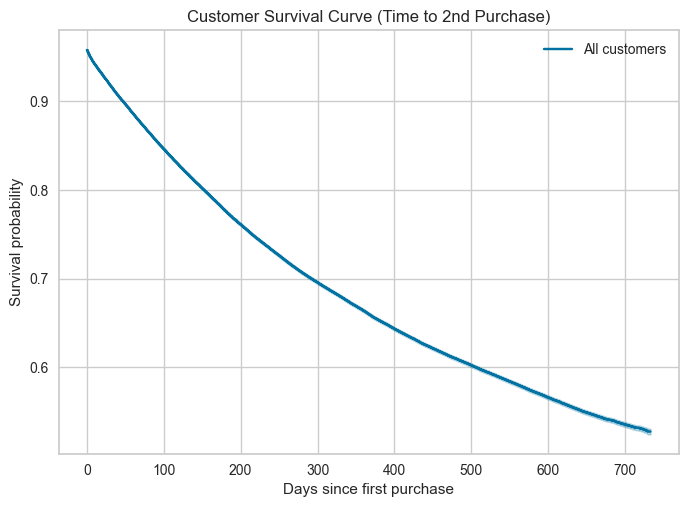

In [ ]:
# Fit Kaplan–Meier survival curve for time to second purchase
kmf = KaplanMeierFitter()

kmf.fit(
    durations=df_survival['duration'],
    event_observed=df_survival['event'],
    label='All customers'
)

kmf.plot_survival_function()
plt.title("Customer Survival Curve (Time to 2nd Purchase)")
plt.xlabel("Days since first purchase")
plt.ylabel("Survival probability")
plt.show()

In [ ]:
# sum of purchase
first_purchase = df.sort_values('t_dat').groupby(['customer_id', 't_dat'])['price'].sum().reset_index().groupby('customer_id').first().reset_index()  

df_survival = df_survival.merge(
    first_purchase[['customer_id', 'price']],
    on='customer_id',
    how='left'
)

df_survival.rename(
    columns={'price': 'first_purchase_spend'},
    inplace=True
)
df_survival.head(1)

,customer_id,first_purchase_date,second_purchase_date,observation_end,duration,event,first_purchase_spend
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,2018-09-25,2019-05-07,2020-09-22,224,1,0.033881


- CoxPH model

In [ ]:
# To examine whether first purchase spend influences customer survival (repeat purchase behaviour).
cox_df = df_survival[['duration', 'event', 'first_purchase_spend']].copy()

# The price values are small(between 0 and 1) and more easier interpreation, a log transformation was applied.
cox_df['log_first_purchase_spend'] = np.log(cox_df['first_purchase_spend'] + 1e-6)

cph = CoxPHFitter()
cph.fit(
    cox_df[['duration', 'event', 'log_first_purchase_spend']],
    duration_col='duration',
    event_col='event'
)

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 332804 total observations, 221323 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 332804
number of events observed = 111481
   partial log-likelihood = -1362863.92
         time fit was run = 2025-12-27 12:35:55 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                 
log_first_purchase_spend  0.29      1.33      0.00            0.28            0.30                1.32                1.35

                          cmp to     z      p  -log2(p)
covariate                                              
log_first_purchase_spend    0.00 61.51 <0.005       inf
---
Concordance = 0.57
Partial AIC = 2725729.84
log-likelihood ratio test = 3850.61 on 1 df
-log2(p) of ll-ratio test = inf

-----

## 3. Behavioural segmentation of one-day and repeat customers
### Do one-day and repeat buyers form distinct behavioural clusters, and how can these differences inform targeted marketing strategies?



- Creating behavioural Data through Feature Engineering

RFM Features

1) Recency (R)

In [11]:
customer_data = df.groupby('customer_id')['t_dat'].max().reset_index()
customer_data[:1]

,customer_id,t_dat
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,2019-05-07


In [12]:
most_recent_data = df['t_dat'].max()
print('most recent date :' , most_recent_data)

most recent date : 2020-09-22 00:00:00


In [13]:
customer_data['Days_Since_Last_Purchase'] = (most_recent_data - customer_data['t_dat']).dt.days
customer_data.drop(columns=['t_dat'], inplace=True)
customer_data[:1]

,customer_id,Days_Since_Last_Purchase
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,504


2. Frequency (F)

In [14]:
total_transactions = df.groupby('customer_id')['t_dat'].nunique().reset_index()
total_transactions.rename(columns={'t_dat':'Total_Transactions'}, inplace=True)
total_transactions[:1]

,customer_id,Total_Transactions
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,2


In [15]:
# To make the sum
df['count'] = 1
total_products_purchased = df.groupby('customer_id')['count'].sum().reset_index()
total_products_purchased.rename(columns={'count':'Total_Products_Purchased'}, inplace=True)
total_products_purchased[:1]

,customer_id,Total_Products_Purchased
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,2


In [16]:
# First merge
customer_data = pd.merge(customer_data, total_transactions, on='customer_id')
customer_data = pd.merge(customer_data, total_products_purchased, on='customer_id')
customer_data.head(1)

,customer_id,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,504,2,2


3. Momentary (M)

In [17]:
total_spend = df.groupby('customer_id')['price'].sum().reset_index()
total_spend.rename(columns={'price':'Total_Spend'}, inplace=True)
total_spend.head(1)

,customer_id,Total_Spend
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,0.101661


In [18]:
average_transaction_value = total_spend.merge(total_transactions, on='customer_id')
average_transaction_value['Average_Transaction_Value'] = average_transaction_value['Total_Spend'] / total_transactions['Total_Transactions']
average_transaction_value.head(1)

,customer_id,Total_Spend,Total_Transactions,Average_Transaction_Value
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,0.101661,2,0.050831


In [19]:
# Second merge
customer_data = pd.merge(customer_data, total_spend, on='customer_id')
customer_data = pd.merge(customer_data, average_transaction_value[['customer_id', 'Average_Transaction_Value']], on='customer_id')
customer_data.head(1)

,customer_id,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,504,2,2,0.101661,0.050831


Product Diversity

In [20]:
unique_products_purchased = df.groupby('customer_id')['article_id'].nunique().reset_index()
unique_products_purchased.rename(columns={'article_id':'Unique_Products_Purchased'}, inplace=True)
unique_products_purchased.head(1)

,customer_id,Unique_Products_Purchased
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,2


In [21]:
# Third merge
customer_data = pd.merge(customer_data, unique_products_purchased, on='customer_id')
customer_data.head(1)

,customer_id,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,504,2,2,0.101661,0.050831,2


Behavioral Features

In [22]:
# favorite_shopping_day
df['Day_Of_Week'] = df['t_dat'].dt.dayofweek
favorite_shopping_day = df.groupby(['customer_id', 'Day_Of_Week'])['count'].size().reset_index(name='Count')
favorint_shopping_day = favorite_shopping_day.loc[favorite_shopping_day.groupby('customer_id')['Count'].idxmax()][['customer_id', 'Day_Of_Week']]
favorint_shopping_day.head(1)

,customer_id,Day_Of_Week
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,1


In [23]:
df = df.sort_values(['customer_id', 't_dat'])

days_between_purchase = (
    df.groupby('customer_id')['t_dat']
    .apply(lambda x: x.diff().dt.days.fillna(0)) # customer who purchase over 2 (same day purchase included)
)

average_days_between_purchases = days_between_purchase.groupby('customer_id').mean().reset_index()
average_days_between_purchases.rename(columns={'t_dat':'Average_Days_Between_Purchases'}, inplace=True)
average_days_between_purchases.head(1)

,customer_id,Average_Days_Between_Purchases
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,112.0


In [24]:
# Fourth merge
customer_data = pd.merge(customer_data, average_days_between_purchases, on='customer_id', how = 'left')
customer_data = pd.merge(customer_data, favorint_shopping_day, on='customer_id')
customer_data.head(1)

,customer_id,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,504,2,2,0.101661,0.050831,2,112.0,1


Sales Channel Features

In [25]:
customer_sales_channel = df.groupby('customer_id')['sales_channel_id'].value_counts().unstack().fillna(0)
customer_sales_channel.head(1)

sales_channel_id,1,2
customer_id,,
0000423b00ade91418cceaf3b26c6af3dd342b51fd051eec9c12fb36984420fa,0.0,2.0


In [26]:
customer_main_sales_channel = customer_sales_channel.idxmax(axis=1)
customer_main_sales_channel.name = 'Preferred_Sales_Channel'
customer_main_sales_channel.head(2)

customer_id
0000423b00ade91418cceaf3b26c6af3dd342b51fd051eec9c12fb36984420fa    2
00007d2de826758b65a93dd24ce629ed66842531df6699338c5570910a014cc2    2
Name: Preferred_Sales_Channel, dtype: int64

In [27]:
# Fifth merge
customer_data = pd.merge(customer_data, customer_main_sales_channel, on='customer_id')
customer_data.head(1)

,customer_id,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Preferred_Sales_Channel
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,504,2,2,0.101661,0.050831,2,112.0,1,2


Seasonality & Trend

In [28]:
monthly_spending = df.groupby(['customer_id', 'year', 'month'])['price'].sum().reset_index()
monthly_spending.head(1)

,customer_id,year,month,price
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,2018,9,0.033881


In [29]:
seasonal_buying_patterns = monthly_spending.groupby('customer_id')['price'].agg(['mean', 'std']).reset_index()
seasonal_buying_patterns.rename(columns={'mean':'Monthly_Spending_Mean', 'std':'Monthly_Spending_Std'}, inplace=True)
seasonal_buying_patterns.head(1)

,customer_id,Monthly_Spending_Mean,Monthly_Spending_Std
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,0.050831,0.02397


In [30]:
seasonal_buying_patterns['Monthly_Spending_Std'].fillna(0, inplace=True)

In [31]:
from scipy.stats import linregress
def calculate_trend(spend_data):
  if len(spend_data) > 1:
    x = np.arange(len(spend_data))
    slope, _, _, _, _ = linregress(x, spend_data)
    return slope
  else:
    return 0

In [32]:
spending_trends = monthly_spending.groupby('customer_id')['price'].apply(calculate_trend).reset_index()
spending_trends.rename(columns={'price':'Spending_Trend'}, inplace=True)
spending_trends.head(1)

,customer_id,Spending_Trend
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,0.033898


In [33]:
# Last merge
customer_data = pd.merge(customer_data, seasonal_buying_patterns, on='customer_id')
customer_data = pd.merge(customer_data, spending_trends, on='customer_id')
customer_data.head(1)

,customer_id,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Preferred_Sales_Channel,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,504,2,2,0.101661,0.050831,2,112.0,1,2,0.050831,0.02397,0.033898


In [34]:
# Checking behaviour data 
customer_data['customer_id'] = customer_data['customer_id'].astype(str)
customer_data = customer_data.convert_dtypes()
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332804 entries, 0 to 332803
Data columns (total 13 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   customer_id                     332804 non-null  string 
 1   Days_Since_Last_Purchase        332804 non-null  Int64  
 2   Total_Transactions              332804 non-null  Int64  
 3   Total_Products_Purchased        332804 non-null  Int64  
 4   Total_Spend                     332804 non-null  Float64
 5   Average_Transaction_Value       332804 non-null  Float64
 6   Unique_Products_Purchased       332804 non-null  Int64  
 7   Average_Days_Between_Purchases  332804 non-null  Float64
 8   Day_Of_Week                     332804 non-null  Int32  
 9   Preferred_Sales_Channel         332804 non-null  Int64  
 10  Monthly_Spending_Mean           332804 non-null  Float64
 11  Monthly_Spending_Std            332804 non-null  Float64
 12  Spending_Trend  

In [35]:
# Merge behaviour data and customer info data
customers = pd.read_csv("customers.csv")
merged_df = pd.merge(customer_data, customers, on='customer_id')
merged_df[:2]

,customer_id,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Preferred_Sales_Channel,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend,club_member_status,fashion_news_frequency,age
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,504,2,2,0.101661,0.050831,2,112.0,1,2,0.050831,0.02397,0.033898,ACTIVE,NONE,25.0
1,00007d2de826758b65a93dd24ce629ed66842531df6699...,457,1,1,0.009644,0.009644,1,0.0,6,2,0.009644,0.0,0.0,ACTIVE,Regularly,32.0


In [36]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332804 entries, 0 to 332803
Data columns (total 16 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   customer_id                     332804 non-null  object 
 1   Days_Since_Last_Purchase        332804 non-null  Int64  
 2   Total_Transactions              332804 non-null  Int64  
 3   Total_Products_Purchased        332804 non-null  Int64  
 4   Total_Spend                     332804 non-null  Float64
 5   Average_Transaction_Value       332804 non-null  Float64
 6   Unique_Products_Purchased       332804 non-null  Int64  
 7   Average_Days_Between_Purchases  332804 non-null  Float64
 8   Day_Of_Week                     332804 non-null  Int32  
 9   Preferred_Sales_Channel         332804 non-null  Int64  
 10  Monthly_Spending_Mean           332804 non-null  Float64
 11  Monthly_Spending_Std            332804 non-null  Float64
 12  Spending_Trend  

In [37]:
# Customers who made purchases on only one day and did not return on any other day
one_day_buyer = list(customer_data[customer_data.Average_Days_Between_Purchases == 0].customer_id)

# Customers who made purchases several days
multi_day_buyer = list(customer_data[customer_data.Average_Days_Between_Purchases != 0].customer_id)

In [38]:
len(one_day_buyer), len(multi_day_buyer)

(230366, 102438)

In [39]:
# Seperate the dataset 
one_day_df = merged_df[merged_df['customer_id'].isin(one_day_buyer)]
multi_day_df = merged_df[merged_df['customer_id'].isin(multi_day_buyer)]

In [41]:
multi_day_df.head(1)

,customer_id,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Preferred_Sales_Channel,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend,club_member_status,fashion_news_frequency,age
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,504,2,2,0.101661,0.050831,2,112.0,1,2,0.050831,0.02397,0.033898,ACTIVE,NONE,25.0


In [ ]:
#multi_day_df.to_csv("multi_day_df.csv", index = 0)
#one_day_df.to_csv("one_day_df.csv", index = 0)

----

- Clustering

In [116]:
multi_day_df.drop(columns=['club_member_status', 'fashion_news_frequency'], inplace = True)

In [118]:
multi_day_df.columns

Index(['customer_id', 'Days_Since_Last_Purchase', 'Total_Transactions',
       'Total_Products_Purchased', 'Total_Spend', 'Average_Transaction_Value',
       'Unique_Products_Purchased', 'Average_Days_Between_Purchases',
       'Day_Of_Week', 'Preferred_Sales_Channel', 'Monthly_Spending_Mean',
       'Monthly_Spending_Std', 'Spending_Trend', 'age'],
      dtype='object')

In [ ]:
# Identify behavioural outliers using Isolation Forest to reduce the impact of extreme customers before clustering
multi_day_df

model = IsolationForest(contamination=0.05, random_state=0)
multi_day_df['Outlier_Scores'] = model.fit_predict(multi_day_df.iloc[:, 1:].to_numpy())
multi_day_df['Is_Outlier'] = [1 if x == -1 else 0 for x in multi_day_df['Outlier_Scores']]

multi_day_df.head()

,customer_id,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Preferred_Sales_Channel,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend,age,Outlier_Scores,Is_Outlier
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,504,2,2,0.101661,0.050831,2,112.0,1,2,0.050831,0.02397,0.033898,25.0,1,0
2,00009d946eec3ea54add5ba56d5210ea898def4b46c685...,299,3,3,0.065712,0.021904,3,124.666667,3,2,0.032856,0.011973,-0.016932,56.0,1,0
6,0000f2ea26b7f0a9175f428c8cf7743e9e10e193465ecd...,238,2,2,0.062898,0.031449,2,62.5,1,2,0.031449,0.00344,-0.004864,48.0,1,0
11,0001d44dbe7f6c4b35200abdb052c77a87596fe1bdcc37...,31,5,5,0.160932,0.032186,5,128.8,5,2,0.040233,0.036957,0.026944,44.0,1,0
13,00023e3dd8618bc63ccad995a5ac62e21177338d642d66...,96,3,3,0.083,0.027667,3,101.666667,1,2,0.027667,0.012721,-0.005932,24.0,1,0


In [120]:
multi_day_df['Is_Outlier'].value_counts()

Is_Outlier
0    97316
1     5122
Name: count, dtype: int64

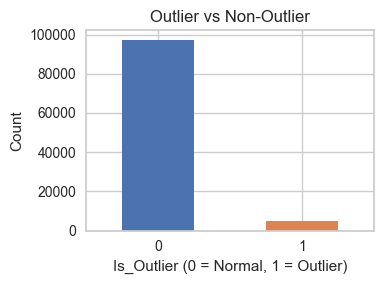

In [ ]:
multi_day_df['Is_Outlier'].value_counts().plot(
    kind='bar',
    figsize=(4, 3),
    color=['#4c72b0', '#dd8452']
)

plt.title('Outlier vs Non-Outlier')
plt.xlabel('Is_Outlier (0 = Normal, 1 = Outlier)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [122]:
# Separate detected outliers from the main dataset
outliers_data = multi_day_df[multi_day_df['Is_Outlier'] == 1]

# Remove outliers to create a cleaned customer dataset
customer_data_cleaned = multi_day_df[multi_day_df['Is_Outlier'] == 0]

# Drop temporary outlier detection columns
customer_data_cleaned.drop(['Outlier_Scores', 'Is_Outlier'], axis=1, inplace=True)

# Reset index after removing outliers
customer_data_cleaned.reset_index(drop=True, inplace=True)
customer_data_cleaned.head()

,customer_id,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Preferred_Sales_Channel,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend,age
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,504,2,2,0.101661,0.050831,2,112.0,1,2,0.050831,0.02397,0.033898,25.0
1,00009d946eec3ea54add5ba56d5210ea898def4b46c685...,299,3,3,0.065712,0.021904,3,124.666667,3,2,0.032856,0.011973,-0.016932,56.0
2,0000f2ea26b7f0a9175f428c8cf7743e9e10e193465ecd...,238,2,2,0.062898,0.031449,2,62.5,1,2,0.031449,0.00344,-0.004864,48.0
3,0001d44dbe7f6c4b35200abdb052c77a87596fe1bdcc37...,31,5,5,0.160932,0.032186,5,128.8,5,2,0.040233,0.036957,0.026944,44.0
4,00023e3dd8618bc63ccad995a5ac62e21177338d642d66...,96,3,3,0.083,0.027667,3,101.666667,1,2,0.027667,0.012721,-0.005932,24.0


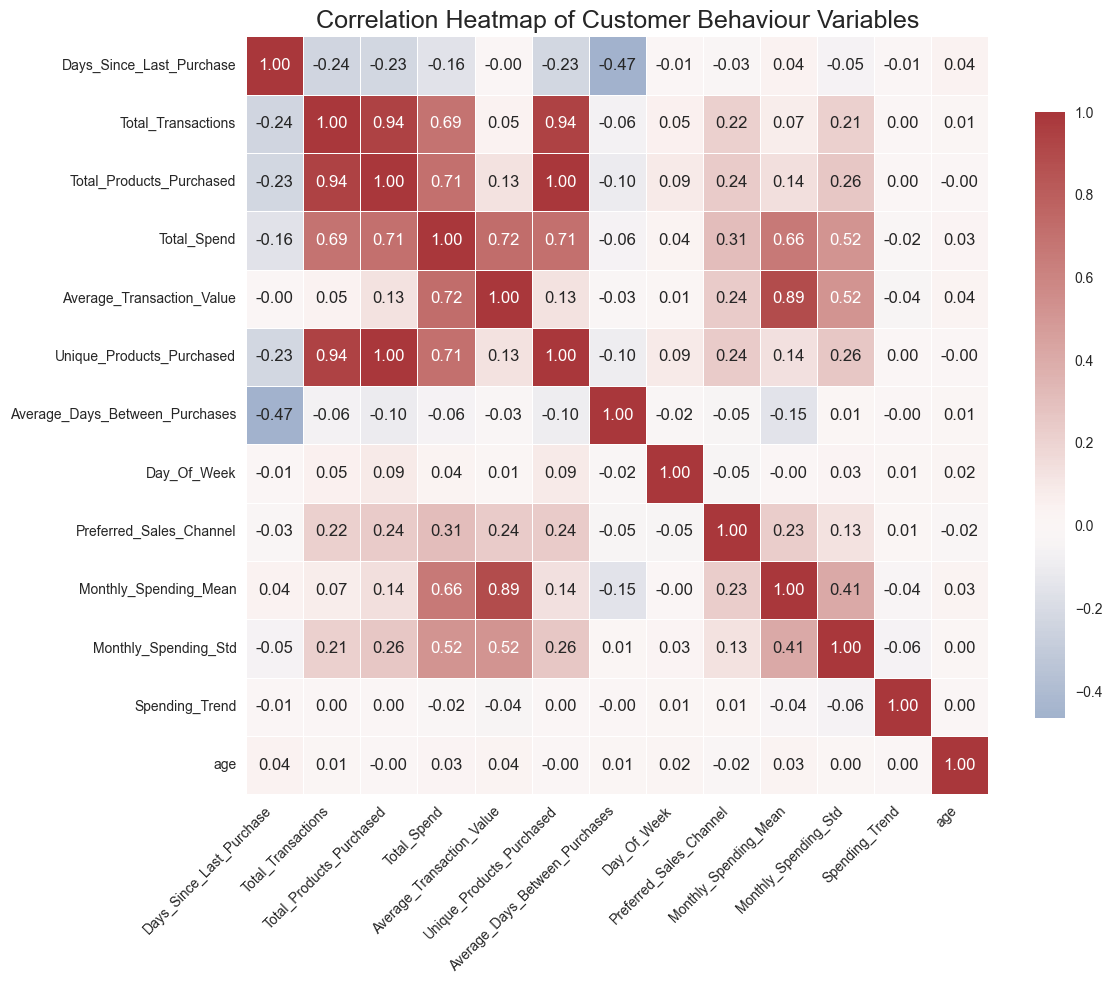

In [123]:
# Corrlation heatmap
corrmat = customer_data_cleaned.iloc[:, 1:].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corrmat,
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap of Customer Behaviour Variables", fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- PCA

In [124]:
# Scaling for PCA execution
scaler = StandardScaler()

# Exclude categorical variables
columns_to_exclude = ['customer_id', 'Day_Of_Week', 'Preferred_Sales_Channel']
columns_to_scale = customer_data_cleaned.columns.difference(columns_to_exclude)
customer_data_scaled = customer_data_cleaned.copy()
customer_data_scaled[columns_to_scale] = scaler.fit_transform(customer_data_scaled[columns_to_scale])
customer_data_scaled.head()

,customer_id,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Preferred_Sales_Channel,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend,age
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,1.587803,-0.623790,-0.670388,0.672410,1.918397,-0.665536,0.085712,1,2,1.497127,0.988174,1.746689,-0.859631
1,00009d946eec3ea54add5ba56d5210ea898def4b46c685...,0.394096,0.420485,0.261538,-0.183949,-0.518813,0.267038,0.262753,3,2,0.211170,-0.093143,-0.835881,1.597509
2,0000f2ea26b7f0a9175f428c8cf7743e9e10e193465ecd...,0.038895,-0.623790,-0.670388,-0.250971,0.285419,-0.665536,-0.606145,1,2,0.110525,-0.862271,-0.222747,0.963408
3,0001d44dbe7f6c4b35200abdb052c77a87596fe1bdcc37...,-1.166457,2.509036,2.125391,2.084332,0.347539,2.132187,0.320524,5,2,0.738952,2.158760,1.393362,0.646358
4,00023e3dd8618bc63ccad995a5ac62e21177338d642d66...,-0.787965,0.420485,0.261538,0.227879,-0.033275,0.267038,-0.058716,1,2,-0.160086,-0.025687,-0.276999,-0.938894


In [ ]:
pca = PCA().fit(customer_data_scaled.iloc[:, 1:])
np.cumsum(pca.explained_variance_ratio_)

array([0.28852488, 0.50122504, 0.65163119, 0.75202882, 0.82220917,
       0.89178301, 0.93691728, 0.96951894, 0.98369462, 0.99209243,
       0.99816481, 0.99982798, 1.        ])

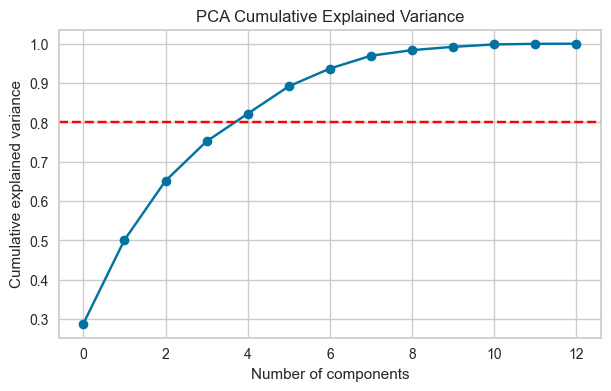

In [127]:
# Select the number of principal components where the cumulative explained variance reaches approximately 80%
pca = PCA().fit(customer_data_scaled.iloc[:, 1:])
plt.figure(figsize=(7, 4))

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(0.8, color='red', linestyle='--')  # 80% baseline

plt.title("PCA Cumulative Explained Variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.show()

In [128]:
pca = PCA(n_components=5)
pca.fit(customer_data_scaled.iloc[:, 1:])
PCA_ds = pd.DataFrame(pca.transform(customer_data_scaled.iloc[:, 1:]), columns=(["PC1","PC2", "PC3", "PC4", "PC5"]))
PCA_ds.describe().T

,count,mean,std,min,25%,50%,75%,max
PC1,97316.0,4.497660e-17,2.031311,-3.628358,-1.500150,-0.506977,0.999405,9.018705
PC2,97316.0,2.441587e-16,1.744089,-3.775711,-1.493046,-0.209237,1.250772,4.608593
PC3,97316.0,-1.518691e-17,1.466620,-5.825666,-0.942552,-0.098572,0.848864,7.402392
PC4,97316.0,-4.380838e-17,1.198248,-3.399119,-0.851315,-0.041694,0.797454,4.196613
PC5,97316.0,-7.301397e-18,1.001827,-5.164175,-0.650993,-0.102129,0.690449,5.288457


In [129]:
PCA_ds

,PC1,PC2,PC3,PC4,PC5
0,0.227176,-1.485598,2.835262,-0.359337,0.623468
1,0.388089,0.911378,-0.238519,-0.244247,0.568087
2,-1.214091,-0.916813,0.584802,-0.399829,0.601003
3,5.345250,1.958776,-0.791339,0.708511,1.315586
4,0.329272,-1.149896,-0.692024,0.352059,-0.844686
...,...,...,...,...,...
97311,-1.516818,0.261728,-0.538771,-0.245455,-0.498067
97312,-1.753008,2.427876,-0.730997,0.820157,1.223776
97313,-0.296687,-0.160838,0.972444,0.503671,0.744332
97314,-0.671140,0.250462,-2.142675,1.041803,-0.833927


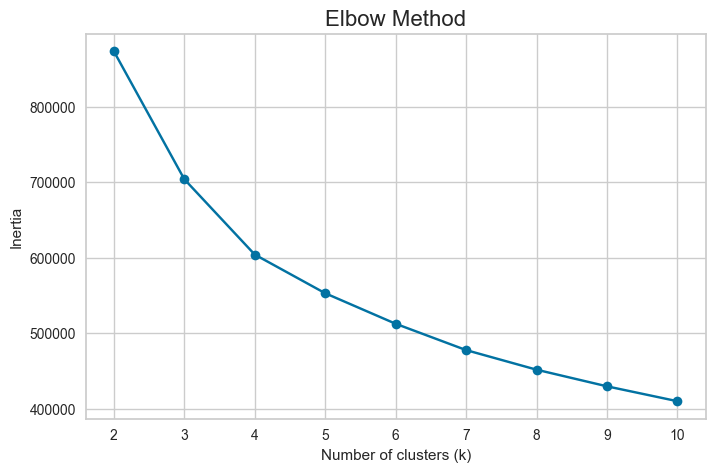

In [ ]:
# Selet K using elbow method
inertia = []
K = range(2, 11)

for k in K:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    km.fit(PCA_ds)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method", fontsize = 16)
plt.show()

- Modeling

In [ ]:
X = PCA_ds

# KMeans
km = KMeans(n_clusters=3, random_state=42, n_init=10)
PCA_ds["label_KMeans"] = km.fit_predict(X) #customer_data_scaled 가 아니고 

# GMM
gmm = GaussianMixture(n_components=3, random_state=42)
PCA_ds["label_GMM"] = gmm.fit_predict(X)

# DBSCAN
db = DBSCAN(eps=0.7, min_samples=10)
PCA_ds["label_DBSCAN"] = db.fit_predict(X)


In [133]:
# len(PCA_ds["label_DBSCAN"].value_counts(normalize=True)) : 42 cluster

# Combine and compare cluster size distributions across K-Means, GMM, and DBSCAN (shown as percentages)
cluster_dist = pd.concat([
    PCA_ds["label_KMeans"].value_counts(normalize=True).rename("K-Means"),
    PCA_ds["label_GMM"].value_counts(normalize=True).rename("GMM"),
    PCA_ds["label_DBSCAN"].value_counts(normalize=True).head(10).rename("DBSCAN")
], axis=1).fillna(0)

cluster_dist_percent = (cluster_dist * 100).round(2)
cluster_dist_percent

,K-Means,GMM,DBSCAN
0,52.34,52.34,16.31
1,30.59,30.59,11.33
2,17.07,17.07,19.70
4,0.00,0.00,15.13
3,0.00,0.00,8.33
-1,0.00,0.00,7.65
10,0.00,0.00,6.38
9,0.00,0.00,2.84
6,0.00,0.00,2.62
7,0.00,0.00,2.56


In [ ]:
# Evaluate clustering quality using internal validation metrics.

def evaluate_clustering(X, labels, model_name):
    # Exclude noise points for DBSCAN evaluation
    if model_name == 'DBSCAN':
        mask = labels != -1
        X_eval = X[mask]
        labels_eval = labels[mask]
        
        # Metrics cannot be computed if fewer than two clusters remain
        if len(np.unique(labels_eval)) < 2:
            return [model_name, len(labels), np.nan, np.nan, np.nan]
    else:
        X_eval = X
        labels_eval = labels

    return [
        model_name,
        len(labels),
        silhouette_score(X_eval, labels_eval),
        calinski_harabasz_score(X_eval, labels_eval),
        davies_bouldin_score(X_eval, labels_eval)
    ]

In [100]:
results = []

# K-Means
results.append(
    evaluate_clustering(X, PCA_ds['label_KMeans'], 'K-Means')
)

# GMM
results.append(
    evaluate_clustering(X, PCA_ds['label_GMM'], 'GMM')
)

# DBSCAN
results.append(
    evaluate_clustering(X, PCA_ds['label_DBSCAN'], 'DBSCAN')
)

In [ ]:
headers = [
    'Model',
    'Num Observations',
    'Silhouette Score',       
    'Calinski-Harabasz Score', 
    'Davies-Bouldin Score' 
]

print(tabulate(results, headers=headers, tablefmt='pretty', floatfmt=".4f"))

+---------+------------------+---------------------+-------------------------+----------------------+
|  Model  | Num Observations |  Silhouette Score   | Calinski-Harabasz Score | Davies-Bouldin Score |
+---------+------------------+---------------------+-------------------------+----------------------+
| K-Means |      97316       | 0.20793465708106387 |   22776.780444400847    |  1.7838807549270144  |
|   GMM   |      97316       | 0.20793465708106387 |   22776.780444400847    |  1.7838807549270144  |
| DBSCAN  |      97316       | 0.2337205539783114  |    9056.512119835239    |  0.9014195888443368  |
+---------+------------------+---------------------+-------------------------+----------------------+


In [135]:
# Assign K-Means cluster labels to the original dataset
customer_data_cleaned['label_KMeans'] = km.fit_predict(X)

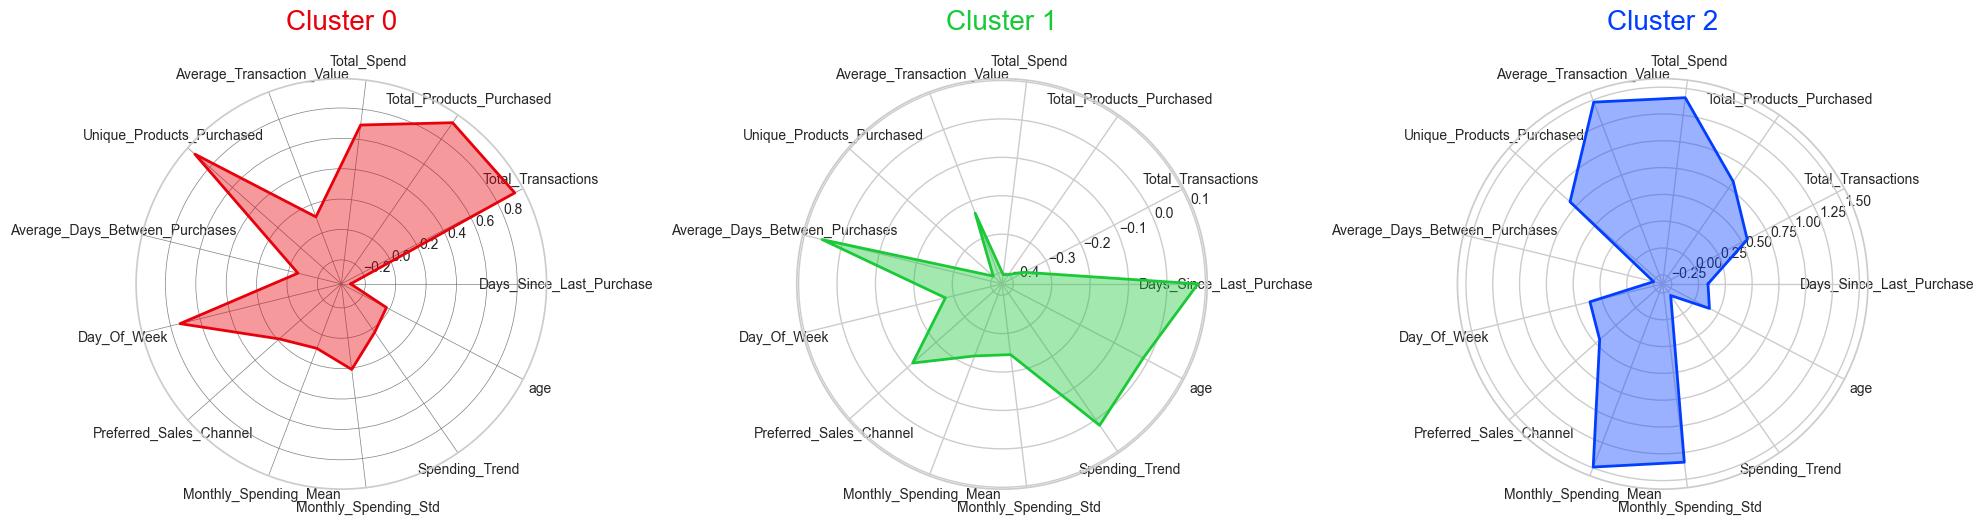

In [136]:
# Visualise cluster characteristics using radar charts

colors = ['#e8000b', '#1ac938', '#023eff']
df_customer = customer_data_cleaned.set_index('customer_id')

scaler = StandardScaler() 
df_customer_standardized = scaler.fit_transform(df_customer.drop(columns=['label_KMeans'], axis=1))

df_customer_standardized = pd.DataFrame(df_customer_standardized, columns=df_customer.columns[:-1], index=df_customer.index)
df_customer_standardized['label_KMeans'] = df_customer['label_KMeans']



cluster_centroids = df_customer_standardized.groupby('label_KMeans').mean()
def create_radar_chart(ax, angles, data, color, cluster):
  ax.fill(angles, data, color=color, alpha=0.4)
  ax.plot(angles, data, color=color, linewidth=2, linestyle='solid')

  ax.set_title(f'Cluster {cluster}', size=20, color=color, y=1.1)

labels = np.array(cluster_centroids.columns)
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

labels = np.concatenate((labels, [labels[0]]))
angles += angles[:1]

fig, ax = plt.subplots(figsize=(20, 10), subplot_kw=dict(polar=True), nrows=1, ncols=3)

for i, color in enumerate(colors):
  data = cluster_centroids.loc[i].tolist()
  data += data[:1]
  create_radar_chart(ax[i], angles, data, color, i)

ax[0].set_xticks(angles[:-1])
ax[0].set_xticklabels(labels[:-1])

ax[1].set_xticks(angles[:-1])
ax[1].set_xticklabels(labels[:-1])

ax[2].set_xticks(angles[:-1])
ax[2].set_xticklabels(labels[:-1])

ax[0].grid(color='grey', linewidth=0.5)

plt.tight_layout()
plt.show()

In [137]:
customer_data_cleaned.columns

Index(['customer_id', 'Days_Since_Last_Purchase', 'Total_Transactions',
       'Total_Products_Purchased', 'Total_Spend', 'Average_Transaction_Value',
       'Unique_Products_Purchased', 'Average_Days_Between_Purchases',
       'Day_Of_Week', 'Preferred_Sales_Channel', 'Monthly_Spending_Mean',
       'Monthly_Spending_Std', 'Spending_Trend', 'age', 'label_KMeans'],
      dtype='object')

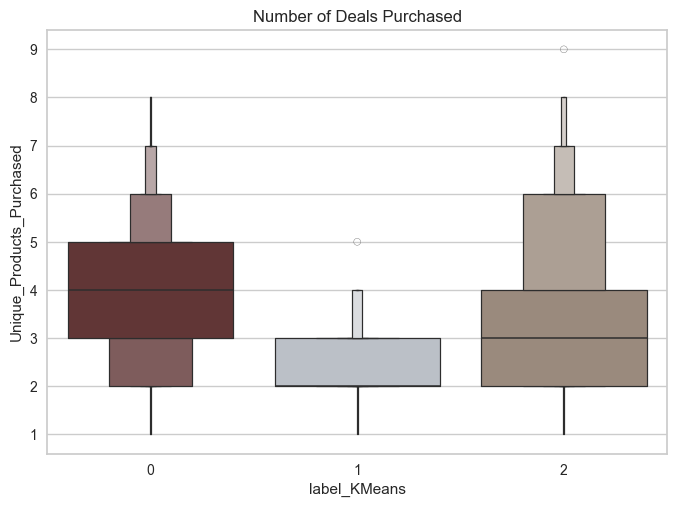

In [ ]:
# Distribution of 'Unique_Products_Purchased'
pal = ["#682F2F","#B9C0C9", "#9F8A78","#F3AB60"]
plt.figure()
pl=sns.boxenplot(y=customer_data_cleaned['Unique_Products_Purchased'],x=customer_data_cleaned["label_KMeans"], palette= pal)
pl.set_title("Unique_Products_Purchased")
plt.show()

To manage package versions for subsequent analyses, a separate virtual environment is used, and the notebook is split accordingly.